
libgomp: Invalid value for environment variable OMP_NUM_THREADS

libgomp: Invalid value for environment variable OMP_NUM_THREADS
IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


---------------------PHASE TRAIN------------------------
	iters: 400, epoch: 1 | time loss: 0.8340793 | fre loss: 12.3046732 | dc loss: 0.8750474 | tfad loss: 0.0187325 | coral loss: 0.0187325
	speed: 0.1558s/iter; left time: 630.3442s
	iters: 800, epoch: 1 | time loss: 0.8557482 | fre loss: 12.3311272 | dc loss: 0.7906972 | tfad loss: 0.0137995 | coral loss: 0.0137995
	speed: 0.1545s/iter; left time: 563.4111s
Epoch: 1
Epoch: 1, Steps: 889 | Train Loss: 0.9883729 Vali Loss: 0.7420665
Validation loss decreased (inf --> 0.742067).  Saving model ...
Updating learning rate to 0.0001
	iters: 400, epoch: 2 | time loss: 0.2823496 | fre loss: 16.1787338 | dc loss: 0.2601410 | tfad loss: 0.0002438 | coral loss: 0.0002438
	speed: 0.2911s/iter; left time: 918.9850s
	iters: 800, epoch: 2 | time loss: 0.2225174 | fre loss: 15.7795229 | dc loss: 0.2575383 | tfad loss: 0.0001118 | coral loss: 0.0001118
	speed: 0.1520s/iter; left time: 419.1404s
Epoch: 2
Epoch: 2, Steps: 889 | Train Loss: 0.4141953 V

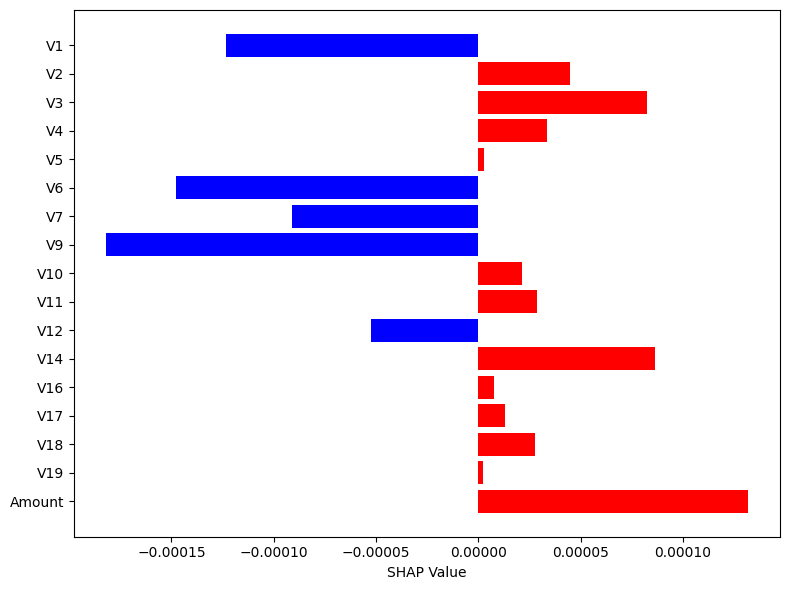

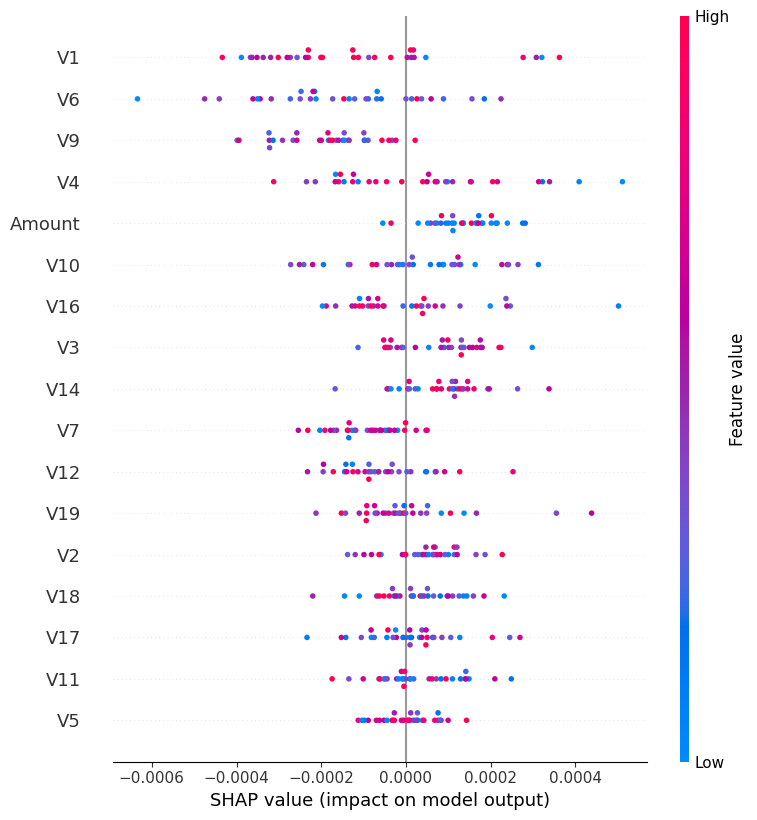

SHAP force plot saved to shap_force.html


In [1]:
from static import *
from config import TransformerConfig
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from loss import frequency_loss, frequency_criterion, coral_loss
from data import split_data, train_val_split, anomaly_detection_data_provider
import os
from CATCH import CATCHModel
import pandas as pd
from earlyStopping import EarlyStopping
from torch.optim import lr_scheduler
import numpy as np
from utils import detect_validate, adjust_learning_rate, padding, coe_batch, mixup_batch, slow_slope, plot_anomaly_detection_result, plot_roc_curve, plot_shap_summary, plot_shap_force
from predict import infer_score, infer_label
from evaluate import calculate
from copy import deepcopy
from json import load
import time
import shap
import matplotlib.pyplot as plt

if __name__ == "__main__":
    dataset_name = "Credit"
    mode = "score"
    with open(os.path.join("config",dataset_name+".json"), "r") as f:
        config = load(f)
    config = TransformerConfig(**config)

    scaler = StandardScaler()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    criterion = nn.MSELoss()
    auxi_loss_fn = frequency_loss(config)
    tfad_criterion = nn.BCEWithLogitsLoss()

    # load data
    train_data, train_label, test_data, test_label = split_data(
        os.path.join("data",dataset_name+".csv"),TRAIN_LENGTH[dataset_name]
    )

    # fit data
    column_num = train_data.shape[1]
    config.enc_in = column_num
    config.dec_in = column_num
    config.c_in = column_num
    config.c_out = column_num
    config.label_len = 48
    model = CATCHModel(config)
    # fix random seed again
    from data import fix_random_seed
    fix_random_seed(2021)
    model.to(device)

    train_data_value, valid_data, train_label_value, valid_label = train_val_split(train_data, train_label, 0.8)
    scaler.fit(train_data_value.values)

    # data preprocess
    train_data_value = pd.DataFrame(
        scaler.transform(train_data_value.values),
        columns=train_data_value.columns,
        index=train_data_value.index,
    )
    valid_data = pd.DataFrame(
        scaler.transform(valid_data.values),
        columns=valid_data.columns,
        index=valid_data.index,
    )
    valid_data_loader = anomaly_detection_data_provider(
        valid_data,
        valid_label,
        batch_size=config.batch_size,
        win_size=config.seq_len,
        step=1,
        mode="val",
    )
    train_data_loader = anomaly_detection_data_provider(
        train_data_value,
        train_label_value,
        batch_size=config.batch_size,
        win_size=config.seq_len,
        step=1,
        mode="train",
    )

    # train
    early_stopping = EarlyStopping(patience=config.patience, verbose=True)
    train_steps = len(train_data_loader)
    main_params = [
        param for name, param in model.named_parameters() if 'mask_generator' not in name
    ]
    optimizer = torch.optim.Adam(main_params, lr=config.lr)
    optimizerM = torch.optim.Adam(model.mask_generator.parameters(), lr=config.Mlr)
    scheduler = lr_scheduler.OneCycleLR(
        optimizer=optimizer,
        steps_per_epoch=train_steps,
        pct_start=config.pct_start,
        epochs=config.num_epochs,
        max_lr=config.lr,
    )
    schedulerM = lr_scheduler.OneCycleLR(
        optimizer=optimizerM,
        steps_per_epoch=train_steps,
        pct_start=config.pct_start,
        epochs=config.num_epochs,
        max_lr=config.Mlr,
    )
    print("---------------------PHASE TRAIN------------------------")
    time_now = time.time()
    for epoch in range(config.num_epochs):
        iter_count = 0
        train_loss = []
        tfad_temp_loss = []
        model.train()

        step = min(int(len(train_data_loader) / 10), 100)
        for i, (input, target) in enumerate(train_data_loader):
            # target: [bs, seq_len, 1]
            # y = target[:, -config.suspect_window_length:, :].squeeze(-1).max(dim=1)[0].float().to(device) # y: [batch_size]
            y = torch.zeros(target.shape[0]).to(device)
            # input: [bs, seq_len, n_vars]
            x = input.float().to(device).permute(0, 2, 1) # x: [bs, n_vars, seq_len]

            if config.coe_rate > 0:
                # print(" coe_rate x shape is", x.shape)
                x_oe, y_oe = coe_batch(
                    x=x,
                    y=y,
                    coe_rate=config.coe_rate,
                    suspect_window_length=config.suspect_window_length,
                    random_start_end=True,
                )
                # Add COE to training batch
                x = torch.cat((x, x_oe), dim=0)
                y = torch.cat((y, y_oe), dim=0)

            if config.mixup_rate > 0.0:
                # print("mixup_rate x shape is", x.shape)
                x_mixup, y_mixup = mixup_batch(
                    x=x,
                    y=y,
                    mixup_rate=config.mixup_rate,
                )
                # Add Mixup to training batch
                x = torch.cat((x, x_mixup), dim=0)
                y = torch.cat((y, y_mixup), dim=0)
                
            if config.slow_slop > 0.0:
                # print("slow_slop x shape is", x.shape)
                x_mixup, y_mixup = slow_slope(
                    x=x,
                    y=y,
                    mixup_rate=config.slow_slop,
                )
                # Add Mixup to training batch
                x = torch.cat((x, x_mixup), dim=0)
                y = torch.cat((y, y_mixup), dim=0)
    
            x = x.permute(0, 2, 1) # x: [bs, seq_len, n_vars]
            iter_count += 1
            optimizer.zero_grad()
            outputs = model(x)
            output = outputs["z"][:, :, :]
            output_complex = outputs["complex_z"]
            dcloss = outputs["dcloss"]
            TFAD_score = outputs["TFAD_score"].reshape(-1)
            z_freq = outputs["z_freq"]
            tfad_embedding_patch = outputs["tfad_embedding_patch"]
            
            rec_loss = criterion(output, x)
            norm_input = model.revin_layer(x, 'transform')
            auxi_loss = auxi_loss_fn(output_complex, norm_input)
            tfad_loss = tfad_criterion(TFAD_score, y)
            z_pool = z_freq.mean(dim=1)
            t_pool = tfad_embedding_patch.mean(dim=1)
            align_loss = coral_loss(z_pool, t_pool)

            loss = rec_loss + config.dc_lambda * dcloss + config.auxi_lambda * auxi_loss + config.tfad_lambda * tfad_loss + config.coral_lambda * align_loss
            train_loss.append(loss.item())
            

            if (i + 1) % step == 0:
                optimizerM.step()
                optimizerM.zero_grad()

            if (i + 1) % 400 == 0:
                print(
                    "\titers: {0}, epoch: {1} | time loss: {2:.7f} | fre loss: {3:.7f} | dc loss: {4:.7f} | tfad loss: {5:.7f} | coral loss: {5:.7f}".format(
                        i + 1,
                        epoch + 1,
                        rec_loss.item(),
                        auxi_loss.item(),
                        dcloss.item(),
                        tfad_loss.item(),
                        align_loss.item()
                    )
                )
                speed = (time.time() - time_now) / iter_count
                left_time = speed * ((config.num_epochs - epoch) * train_steps - i)
                print("\tspeed: {:.4f}s/iter; left time: {:.4f}s".format(speed, left_time))
                iter_count = 0
                time_now = time.time()
                
            loss.backward()
            optimizer.step()

        print("Epoch: {}".format(epoch + 1))
        train_loss = np.average(train_loss)
        valid_loss = detect_validate(model, valid_data_loader, criterion)
        print(
            "Epoch: {0}, Steps: {1} | Train Loss: {2:.7f} Vali Loss: {3:.7f}".format(
                epoch + 1, train_steps, train_loss, valid_loss
            )
        )

        early_stopping(valid_loss, model)
        if early_stopping.early_stop:
            print("Early stopping")
            break

        adjust_learning_rate(optimizer, scheduler, epoch + 1, config)
        adjust_learning_rate(optimizerM, schedulerM, epoch + 1, config, printout=False)

    # validate
    model.load_state_dict(early_stopping.check_point)
    model.to(device)
    model.eval()
    test = pd.DataFrame(
        scaler.transform(test_data.values), columns=test_data.columns, index=test_data.index
    )
    thre_loader = anomaly_detection_data_provider(
        test,
        None,
        batch_size=config.batch_size,
        win_size=config.seq_len,
        step=1,
        mode="thre",
    )
    test_data_loader = anomaly_detection_data_provider(
        test,
        None,
        batch_size=config.batch_size,
        win_size=config.seq_len,
        step=1,
        mode="test",
    )
    time_anomaly_criterion = nn.MSELoss(reduction='none')
    freq_anomaly_criterion = frequency_criterion(config)
    actual_label = test_label.to_numpy().flatten()
    print("---------------------------PHASE TEST-------------------------")
    if mode=="score":
        scores = infer_score(model, thre_loader, time_anomaly_criterion, freq_anomaly_criterion, config.score_lambda)
        predict_labels = deepcopy(scores)
        predict_labels, scores = padding(actual_label, predict_labels, scores)
        results = calculate(mode, actual_label.astype(float), predicted=predict_labels.astype(float))
        print(results)
        # 绘制 ROC 曲线
        # plot_roc_curve(dataset_name, actual_label.astype(float), predict_labels.astype(float))

            # ================== SHAP 分析 ==================
        print("Running SHAP explainability...")
    
        model.eval()
    
        # -------- 1. 构造 wrapper --------
        class ModelWrapper(torch.nn.Module):
            def __init__(self, model):
                super().__init__()
                self.model = model
    
            def forward(self, x):
                # x: [bs, features] -> reshape
                bs = x.shape[0]
                x = x.view(bs, config.seq_len, -1).to(device)
    
                outputs = self.model(x)
                score = outputs["TFAD_score"]  # anomaly score
                return score
    
        wrapped_model = ModelWrapper(model).to(device)
    
        # -------- 2. 取一部分数据作为 background --------
        sample_batch = next(iter(test_data_loader))[0]  # [bs, seq_len, n_vars]
        sample_batch = sample_batch[:64].to(device)
    
        background = sample_batch.view(sample_batch.shape[0], -1)
    
        # -------- 3. 取需要解释的数据 --------
        explain_data = sample_batch[:32]
        explain_data_flat = explain_data.view(explain_data.shape[0], -1)
    
        # -------- 4. SHAP explainer --------
        explainer = shap.GradientExplainer(wrapped_model, background)
    
        shap_values = explainer.shap_values(explain_data_flat)
    
        # shap_values shape: [samples, features]
        shap_values = shap_values[0] if isinstance(shap_values, list) else shap_values
    
        # -------- 5. reshape 回 [samples, seq_len, vars] --------
        shap_values = shap_values.reshape(
            explain_data.shape[0],
            config.seq_len,
            -1
        )
    
        # 对时间维做平均 → 得到每个变量重要性
        shap_var = shap_values.mean(axis=1)  # [samples, vars]
    
        # -------- 6. 计算正负贡献（你要的“相减”效果）--------
        shap_pos = np.clip(shap_var, 0, None).mean(axis=0)
        shap_neg = -np.clip(shap_var, None, 0).mean(axis=0)
    
        shap_diff = shap_pos - shap_neg  # 核心：红 - 蓝
    
        feature_names = test.columns.tolist()
    
        # -------- 7. 自定义 summary bar --------
        # plt.rcParams['font.sans-serif'] = ['SimHei']
        plt.figure(figsize=(8, 6))
    
        y_pos = np.arange(len(feature_names))
    
        colors = ["red" if v > 0 else "blue" for v in shap_diff]
    
        plt.barh(y_pos, shap_diff, color=colors)
    
        plt.yticks(y_pos, feature_names)
        plt.xlabel("SHAP Value")
        # plt.title("Custom SHAP Summary (Difference View)")
    
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()
    
        # -------- 8. SHAP 原生 summary（颜色带）--------
        shap.summary_plot(
            shap_var,
            features=explain_data[:, -1, :].cpu().numpy(),
            feature_names=feature_names
        )
    
        # -------- 9. force plot（变量级解释）--------
        shap.initjs()
        
        # base value
        base_value = float(
            wrapped_model(background).detach().cpu().numpy().mean()
        )
        
        # ✅ 关键：对时间维做平均
        shap_var_single = shap_values[0].mean(axis=0)  # [n_vars]
        
        # 对应输入
        input_var = explain_data[0].mean(axis=0).cpu().numpy()
        
        # 转 float64（避免 JSON 报错）
        shap_var_single = shap_var_single.astype(np.float64)
        input_var = input_var.astype(np.float64)
        
        force_plot = shap.plots.force(
            base_value,
            shap_var_single,
            input_var,
            feature_names=feature_names
        )
        
        shap.save_html("shap_force.html", force_plot)
        
        print("SHAP force plot saved to shap_force.html")
    
    elif mode=="label":
        if not isinstance(config.anomaly_ratio, list):
            config.anomaly_ratio = [config.anomaly_ratio]
        predict_labels, scores = infer_label(model, thre_loader, time_anomaly_criterion, freq_anomaly_criterion, config.score_lambda, train_data_loader, test_data_loader, config.anomaly_ratio)
        results_list = []
        best_f1 = 0
        best_ratio = 0
        best_predict_label = None
        for ratio, predict_label in predict_labels.items():
            predict_label, scores = padding(actual_label, predict_label, scores)
            results = calculate(mode, actual_label.astype(float), predicted=predict_label.astype(float))
            results["ratio"] = ratio
            if results["f_score"] > best_f1:
                best_f1 = results["f_score"]
                best_ratio = ratio
                best_results = results
                best_predict_label = deepcopy(predict_label)
            print(results)
        print("The best f1 is {} with the ratio of {}".format(best_f1, best_ratio))
        
        all_real_labels = np.concatenate([train_label.to_numpy().flatten(), test_label.to_numpy().flatten()])
        plot_anomaly_detection_result(dataset_name, all_real_labels, best_predict_label)